In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt

import sys
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
%matplotlib widget 

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
#run = 104 #XAS step mono
#run = 119 #waveplate
#run = 151 #fixed energy
#run = 76 #XAS fly mono

bg = 3
run = 47

#exp = 'rix100836924'
exp = 'rix101265125'
#79,81,82,83,85,94,95,96,98



#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
#bgname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{bg:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bg:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
# with h5py.File(fname, 'r') as fh:
#     data = SmallData(fh,fyaml)
#     with h5py.File(bgname, 'r') as fhbg:
#         red =Reduced(fh,fhbg,fyaml,clear_memory=False)

#with SmallData(fname,fyaml) as data:
# with Reduced(fname,bgname,fyaml) as red:
#     red.data.integrating.axis_svls.full_area

#red = Reduced(fname,bgname,fyaml,scantype='mono_fly')
data = SmallData(fname,fyaml)
bg = SmallData(bgname, bgyaml)

In [ ]:
red = Reduced(fname,bgname,fyaml,bgyaml,scantype='mono_fly')


accessing intgrp
initialising <HDF5 group "/intg/andor_vls" (63 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (64 members)>
setting up properties
apds does not exits 
apds does not exits 
accessing scan variable
accessing intgrp
initialising <HDF5 group "/intg/andor_vls" (94 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (97 members)>
setting up properties
accessing scan variable
<KeysViewHDF5 ['Sums', 'epics_archiver', 'intg', 'timestamp', 'timing']>
scantype is mono_fly
fly scan!
(151,)
(151,)
andor_vls_on_sum
fly scan!
(151,)
(151,)
axis_svls_on_sum


In [7]:
red.data.integrating.andor_vls.mono_encoder

array([-59666834, -59678214, -59686130, ..., -59453449, -59462852,
       -59350953])

In [1]:
def myround(x, base=5):
    return base * np.round(x/base)

def hrencoder_to_pitch(hrencoder,hr_fit):
    '''Calibration from high rate encoder to grating pitch in urad'''
    return np.polyval(hr_fit,hrencoder)

def get_premirror_pitch(premirror_pitch):
    try:
        return np.nanmean(myround(premirror_pitch,1))
    except:
        # This needs improving
        print('Add SP1K1:MONO:MMS:M_PI.RBV to epics config')
        return 144506
    
def mono_energy(pitchG,pitchM2,stateG = 'LRG'):
    '''Calculator for RIXS mono calibration. This is the same function as what is saved to the mono eV epics variable. 
    pitchG: Grating pitch in urad
    pitchM2: Pre-mirror pitch in urad.
    see: /sdf/home/d/dgarratt/chemRIXS/Modules/Mono_calib_constants.txt
    '''
    import yaml
    with open('../mono_calib.yml', 'r') as file:
        fy = yaml.safe_load(file)
    if stateG=='LRG': #low resolution grating
        D0 = fy['D0_LRG']
        offsetG = fy['offsetG_LRG']
    elif stateG=='LEG': #low energy grating
        D0 = fy['D0_LEG']
        offsetG = offsetG_LEG 
    elif stateG=='MEG': #medium energy grating
        D0 = fy['D0_MEG']
        offsetG = offsetG_LRG
    elif stateG=='HEG': #high energy grating
        D0 = fy['D0_HEG']
        offsetG = offsetG_HEG

     # constants
    eVmm = 0.001239842 # Wavelenght[mm] = eVmm/Energy[eV]
    m = 1 # diffraction order

    offsetM2 = 90641.0e-6 
    thetaM1 = 0.03662
    thetaES = 0.1221413
    
    pG = pitchG*1e-6 - offsetG
    pM2 = pitchM2*1e-6 - offsetM2
    alpha = np.pi/2 - pG + 2*pM2 - thetaM1
    beta = -np.pi/2 - pG + thetaES
    E = m*D0*eVmm/(np.sin(alpha) + np.sin(beta))
    Cff = np.cos(beta)/np.cos(alpha)

    #print('Calculated photon energy {0:6.2f} eV, Cff {1:3.2f}'.format(E, Cff))
    return E

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy


array([0.8023199 , 0.80211731, 0.80197645, ..., 0.80613852, 0.80596945,
       0.80798627])

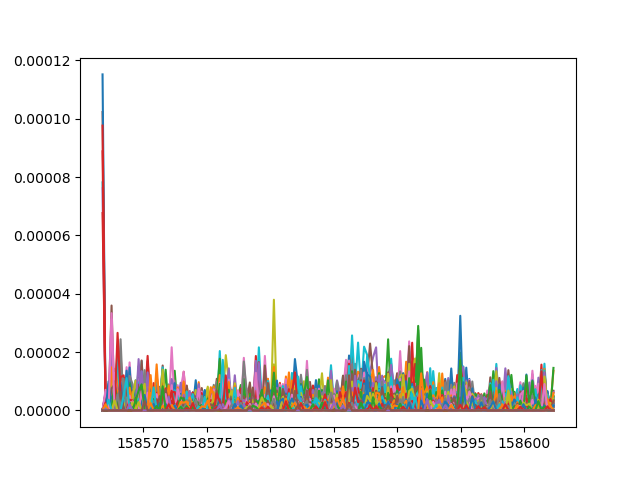

In [5]:
fig,ax=plt.subplots(1,1)

#ax.plot(np.nansum(data.integrating.axis_svls.full_area,axis=0))
ax.plot(red.scanvar_on,red.axis_svls_on_mean)

(array([6690.,    0.,    0.,    0., 1175., 6676.,    0.,    0.,    0.,
          53.]),
 array([767.50770187, 767.6825416 , 767.85738132, 768.03222104,
        768.20706076, 768.38190049, 768.55674021, 768.73157993,
        768.90641965, 769.08125938, 769.2560991 ]),
 <BarContainer object of 10 artists>)

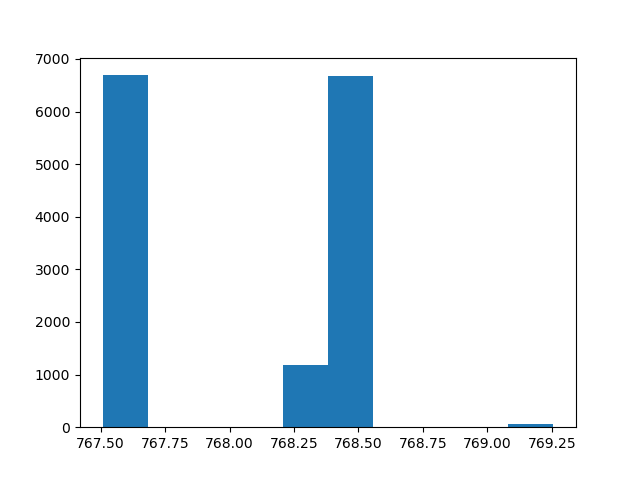

In [12]:
fig,ax=plt.subplots(1,1)
ax.hist(red.data.integrating.andor_vls.mono[onmask])

In [6]:
red.data.integrating.andor_vls.full_area.shape

(29187, 2048)

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.andor_vls_off)
ax.plot(red.andor_vls_off)

In [ ]:
cal=[-9.86289253e-04,  1.01299833e+03]
hrencoder = red.data.integrating.andor_vls.mono_encoder

np.polyval(cal,hrencoder)

In [ ]:
sm = SmallData(fname,fyaml)

In [ ]:
dat = h5py.File(fname, 'r')
dat['intg']['axis_svls'].keys()

In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [2]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=41
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1.keys()


NameError: name 'base_folder' is not defined

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

['/epics_archiver/SP1K1_MONO_MMS_M_PI.RBV']
